## [Appendix C — SARIMA and Momentum-based Stock Forecasting Prototype]

This appendix illustrates a simplified stock forecasting prototype used to demonstrate the dual-scenario forecasting approach described in EVIDENCE 2.
The example uses a representative synthetic weekly stock time series, fitted with a lightweight SARIMA model and complemented by a trend-continuation momentum projection based on the recent four-week gradient.
Both forecasting scenarios are exported for use in Tableau and visualised below.

Note: This appendix provides a simplified prototype for illustration.
In the operational workflow described in Evidence 2, SARIMA hyperparameters were tuned using MAPE to optimise forecasting accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
# ------------------------------
# 1. Generate synthetic weekly stock series
# ------------------------------
np.random.seed(42)

# 52 weeks of historical data (1 year, weekly)
date_index = pd.date_range(start="2024-01-01", periods=52, freq="W")

# Smooth downward trend + mild noise
trend = 120 - np.arange(52) * 0.5        # from 120 downwards
noise = np.random.normal(loc=0.0, scale=2.0, size=52)

stock_level = trend + noise

df = pd.DataFrame({"date": date_index, "stock_level": stock_level})
df = df.set_index("date")
df = df.asfreq("W")
# Ensure no negative stock
df["stock_level"] = df["stock_level"].clip(lower=0)

print(df.head())

            stock_level
date                   
2024-01-07   120.993428
2024-01-14   119.223471
2024-01-21   120.295377
2024-01-28   121.546060
2024-02-04   117.531693


In [3]:
# ------------------------------
# 2. Fit a simple, stable SARIMA model
# ------------------------------
# Using ARIMA(0,1,0) with a trend term:
# - order=(0,1,0): random walk with drift (allows linear trend via 'trend="t"')
# - seasonal_order=(1,0,0,12): light seasonal AR component with yearly cycle (12 weeks)
# - trend="t": includes a deterministic linear trend term (upward or downward)
# This specification captures general downward tendency in stock and avoids overfitting.
model = SARIMAX(
    df["stock_level"],
    order=(0, 1, 0),              # random walk with drift (integrated model)
    seasonal_order=(1, 0, 0, 12), # mild seasonal AR structure
    enforce_stationarity=True,
    enforce_invertibility=True,
    trend="t"                     # linear deterministic trend
)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        stock_level   No. Observations:                   52
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -121.069
Date:                            Thu, 04 Dec 2025   AIC                            248.138
Time:                                    13:01:30   BIC                            253.933
Sample:                                01-07-2024   HQIC                           250.352
                                     - 12-29-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift         -0.0149      0.012     -1.201      0.230      -0.039       0.009
ar.S.L12       0.0003      0.154   

In [4]:
# ------------------------------
# 3. Forecast the next N weeks with SARIMA
# ------------------------------
n_forecast_weeks = 16
forecast_res = results.get_forecast(steps=n_forecast_weeks)
sarima_mean = forecast_res.predicted_mean

sarima_index = pd.date_range(
    start=df.index[-1] + pd.offsets.Week(1),
    periods=n_forecast_weeks,
    freq="W",
)

sarima_series = pd.Series(sarima_mean.values, index=sarima_index, name="sarima_forecast")

In [5]:
# ------------------------------
# 4. Trend continuation momentum projection
#    (use average gradient over last 4 weeks)
# ------------------------------
last_values = df["stock_level"].iloc[-5:]          # last 5 points to compute recent slope
recent_diffs = last_values.diff().dropna()         # 4 recent weekly changes
avg_weekly_change = recent_diffs.mean()            # mean gradient

start_value = df["stock_level"].iloc[-1]

momentum_values = [
    start_value + (i + 1) * avg_weekly_change      # one-step-ahead extension of recent trend
    for i in range(n_forecast_weeks)
]

momentum_series = pd.Series(
    momentum_values,
    index=sarima_index,
    name="momentum_projection",
)


In [6]:
# ------------------------------
# 5. Combine historical + both scenarios for Tableau
# ------------------------------
combined = pd.concat(
    [
        df[["stock_level"]].rename(columns={"stock_level": "historical_stock"}),
        sarima_series,
        momentum_series,
    ],
    axis=1,
)

print(combined.tail())

# Export to CSV for Tableau (uncomment when ready)
combined.to_csv("stock_forecast_scenarios.csv", index=True)

            historical_stock  sarima_forecast  momentum_projection
2025-03-23               NaN        83.414952            79.076608
2025-03-30               NaN        82.458178            77.855506
2025-04-06               NaN        81.486453            76.634404
2025-04-13               NaN        80.499778            75.413302
2025-04-20               NaN        79.498153            74.192199


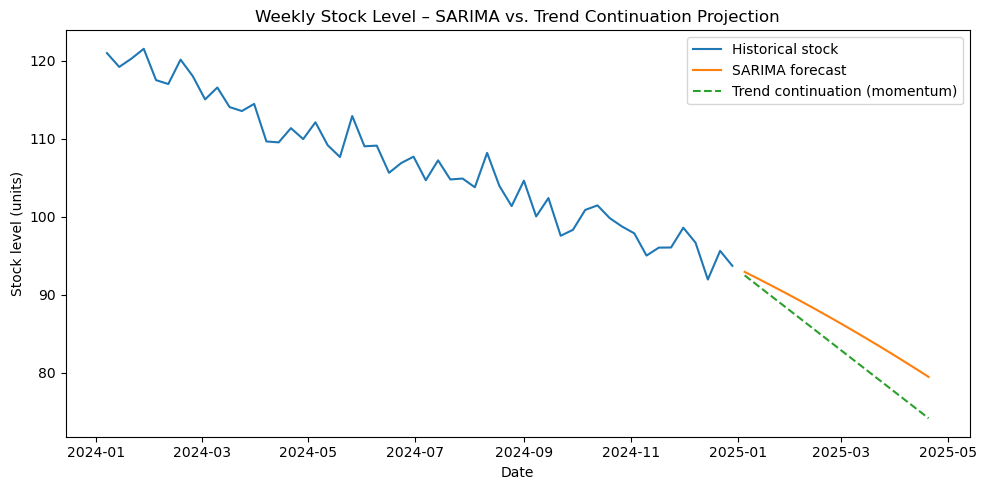

In [7]:
# ------------------------------
# 6. Plot historical + SARIMA + momentum for quick visual check
# ------------------------------
plt.figure(figsize=(10, 5))

# Historical
plt.plot(
    combined.index,
    combined["historical_stock"],
    label="Historical stock",
)

# SARIMA forecast
plt.plot(
    sarima_series.index,
    sarima_series,
    label="SARIMA forecast",
)

# Momentum projection
plt.plot(
    momentum_series.index,
    momentum_series,
    linestyle="--",
    label="Trend continuation (momentum)",
)

plt.title("Weekly Stock Level – SARIMA vs. Trend Continuation Projection")
plt.xlabel("Date")
plt.ylabel("Stock level (units)")
plt.legend()
plt.tight_layout()
plt.show()

Figure 1. Comparison of SARIMA-based forecast and trend continuation projection (16-week horizon).